In [1]:
# 6-24-2026

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import regionmask
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [3]:
transfer_matrix = pd.read_csv("transfer-matrix/rf_transfer_matrix.csv")

In [4]:
transfer_matrix.set_index("Unnamed: 0", inplace=True)
transfer_matrix.index.name = None

In [5]:
transfer_matrix

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770
6,0.178282,0.238235,0.034447,0.220869,0.191487,0.317381,0.118250,0.163631,0.119401,0.021430,...,0.202794,0.247076,0.125801,0.255555,0.201974,-0.068777,0.099243,0.321076,0.102840,-0.017236
7,0.113396,0.054282,0.061550,0.069370,0.044484,0.109329,0.329688,0.092023,0.159883,0.051387,...,0.184071,0.179713,0.142222,0.192045,0.209176,0.035736,0.042035,0.159817,0.008022,0.022467
8,0.181002,0.228547,-0.006209,0.023346,0.133774,0.117255,0.194411,0.424899,0.064289,-0.004919,...,0.093679,0.136592,0.101116,0.173933,0.095452,-0.003312,0.050942,0.240088,0.051530,0.007182
11,0.214508,0.227264,0.109767,0.124790,0.237549,0.076848,0.107019,0.207917,0.551275,-0.003236,...,0.256072,0.166287,0.102690,0.366209,0.181682,-0.007782,0.147501,0.206234,-0.057620,0.064859
12,0.118927,0.175802,-0.016922,0.112255,0.159920,0.070012,0.077276,0.026258,0.103184,0.502334,...,0.163311,-0.091433,0.060118,0.163172,0.119053,0.080449,0.089125,0.118189,0.068853,-0.070408


In [6]:
transfer_matrix.shape

(34, 34)

In [7]:
zarr_path = "data/ecoregion_domains.zarr"

In [8]:
regimes = xr.open_zarr(zarr_path, consolidated=True)

In [9]:
print(regimes)

<xarray.Dataset> Size: 2MB
Dimensions:    (latitude: 720, longitude: 1440)
Coordinates:
  * latitude   (latitude) float64 6kB 89.88 89.62 89.38 ... -89.38 -89.62 -89.88
  * longitude  (longitude) float64 12kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    domain_id  (latitude, longitude) int16 2MB dask.array<chunksize=(180, 720), meta=np.ndarray>


In [10]:
domains = regimes["domain_id"]

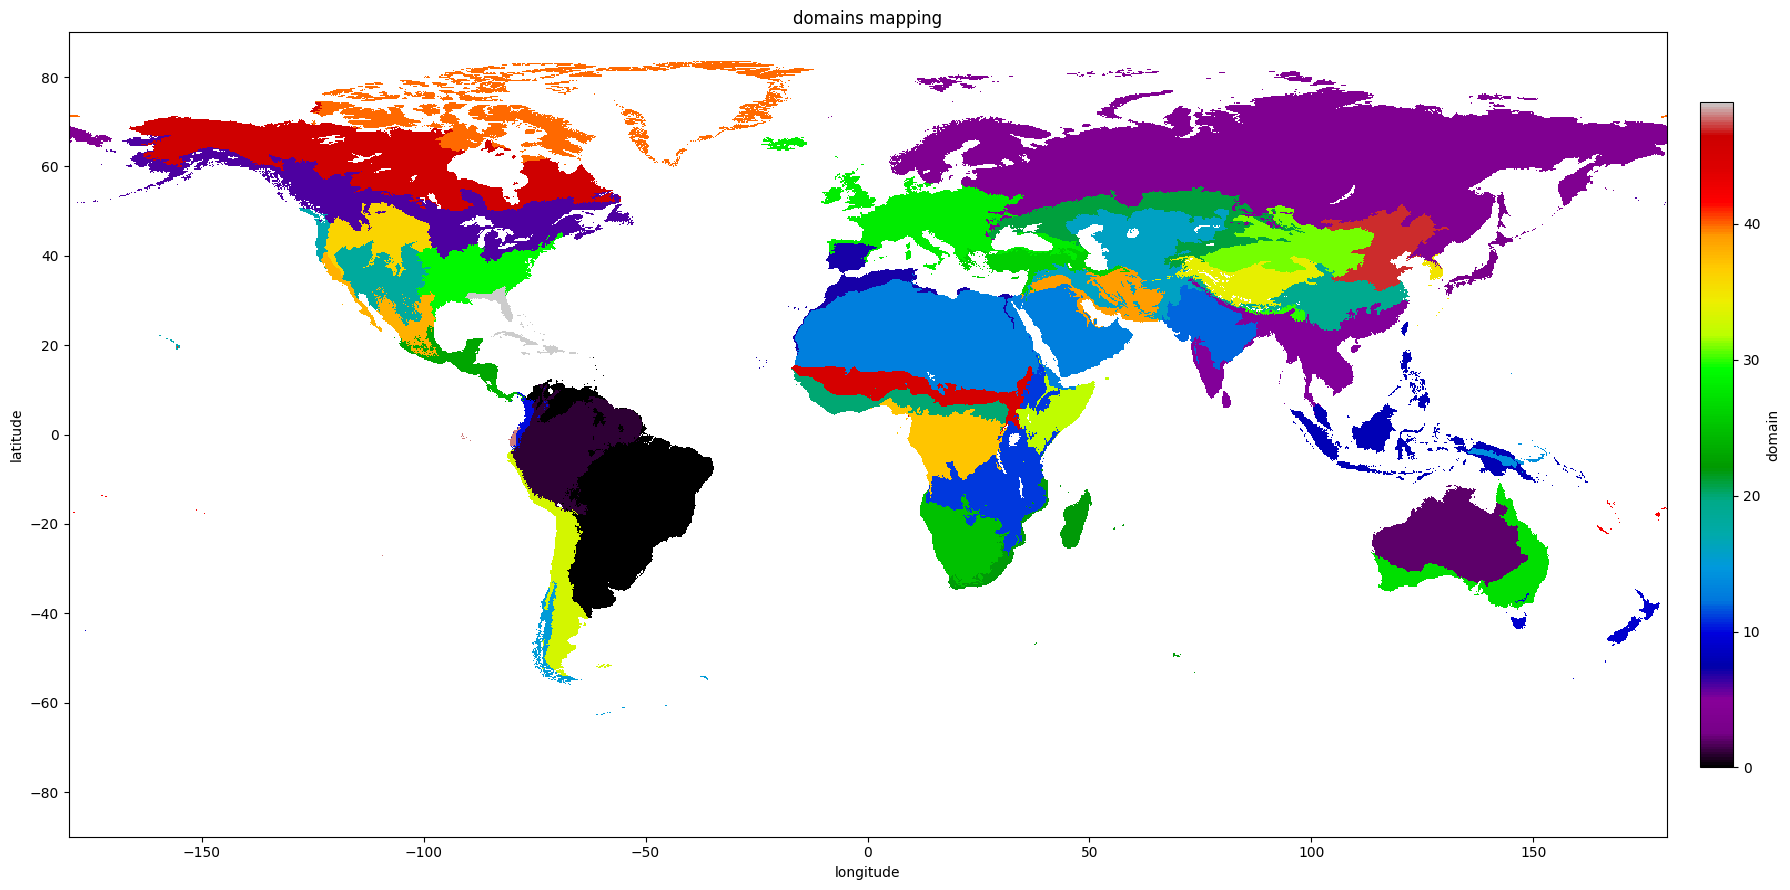

In [11]:
data = domains.values.astype(float)
data[data == -1] = np.nan  # replace fill value with nan

cmap = plt.cm.nipy_spectral.copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(18, 9))

img = ax.imshow(
    data,
    origin="upper",
    extent=[-180, 180, -90, 90],
    cmap=cmap,
    interpolation="none",
    aspect="auto",
)

cbar = fig.colorbar(img, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("domain")

ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("domains mapping")

plt.tight_layout()
plt.show()

In [12]:
VIVID_COLORS = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990",
    "#dcbeff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#a9a9a9", "#ffffff",
]

def plot_domain(domain_ids, data=data):
    land = np.where(~np.isnan(data), 1.0, np.nan)
    land_cmap = plt.cm.colors.ListedColormap(["lightgray"])
    land_cmap.set_bad("white")

    fig, ax = plt.subplots(figsize=(18, 9))
    ax.imshow(land, origin="upper", extent=[-180, 180, -90, 90],
              cmap=land_cmap, interpolation="none", aspect="auto")

    for domain_id, color in zip(domain_ids, VIVID_COLORS):
        mask = np.where(data == domain_id, 1.0, np.nan)
        cmap = plt.cm.colors.ListedColormap([color])
        cmap.set_bad("none")

        ax.imshow(mask, origin="upper", extent=[-180, 180, -90, 90],
                  cmap=cmap, interpolation="none", aspect="auto")
        ax.contour((data == domain_id).astype(float), levels=[0.5],
                   colors=["black"], linewidths=0.8,
                   extent=[-180, 180, -90, 90], origin="upper")

    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(f"domains {domain_ids}")
    plt.tight_layout()
    plt.show()


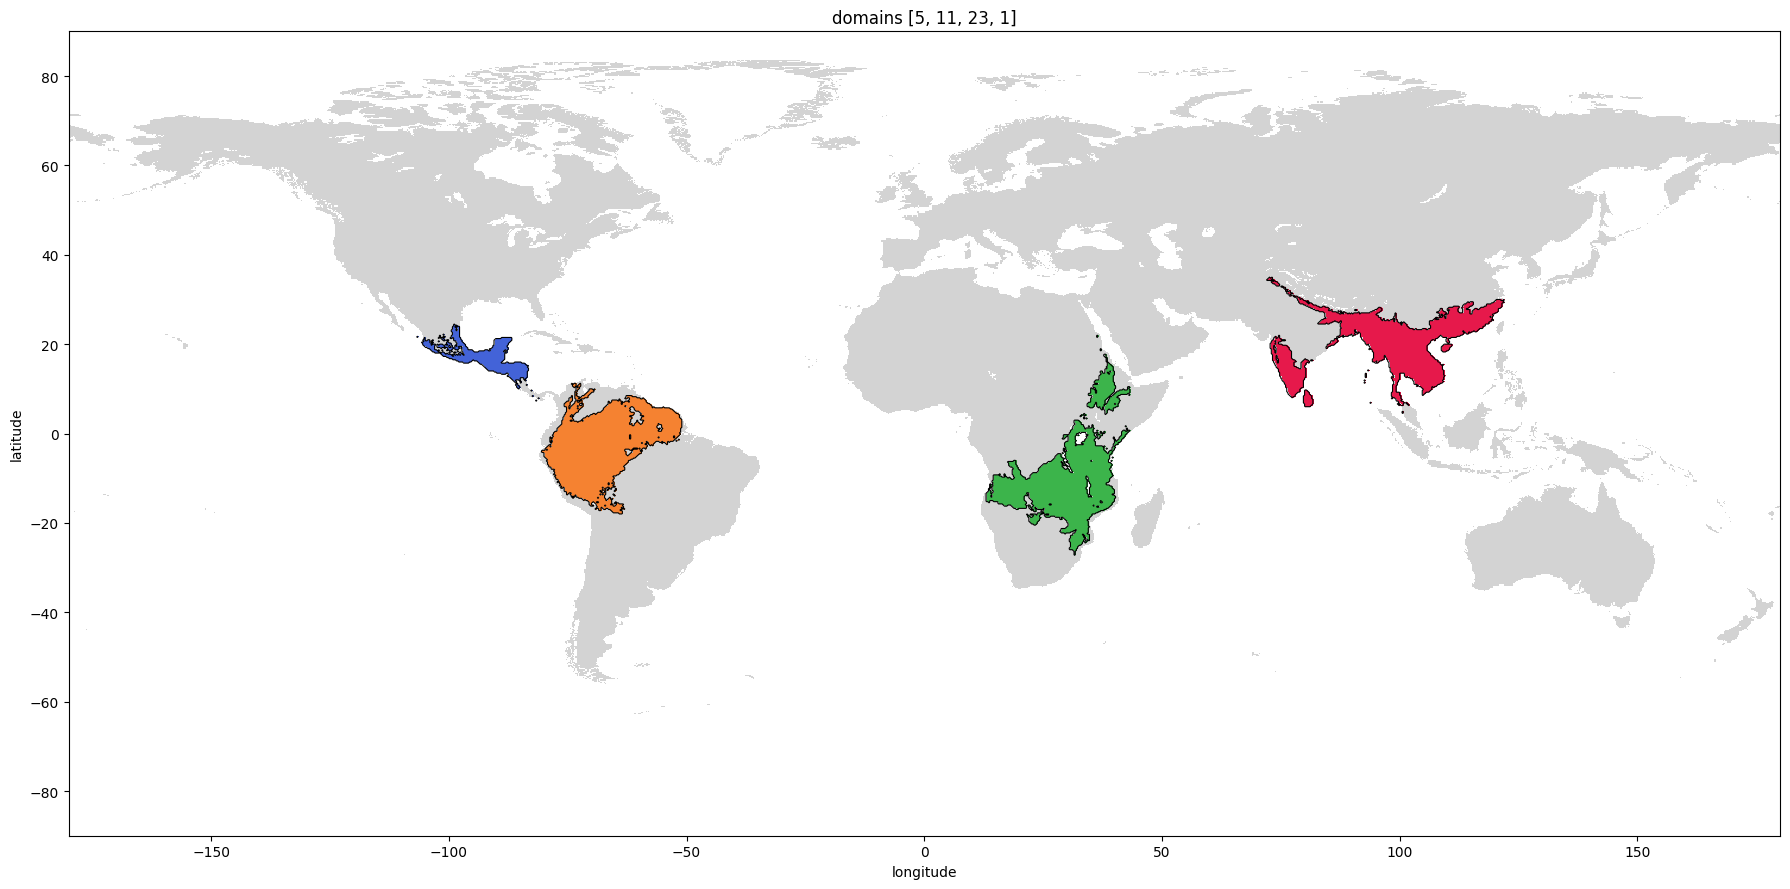

In [13]:
plot_domain([5, 11, 23, 1]) # awesome it works

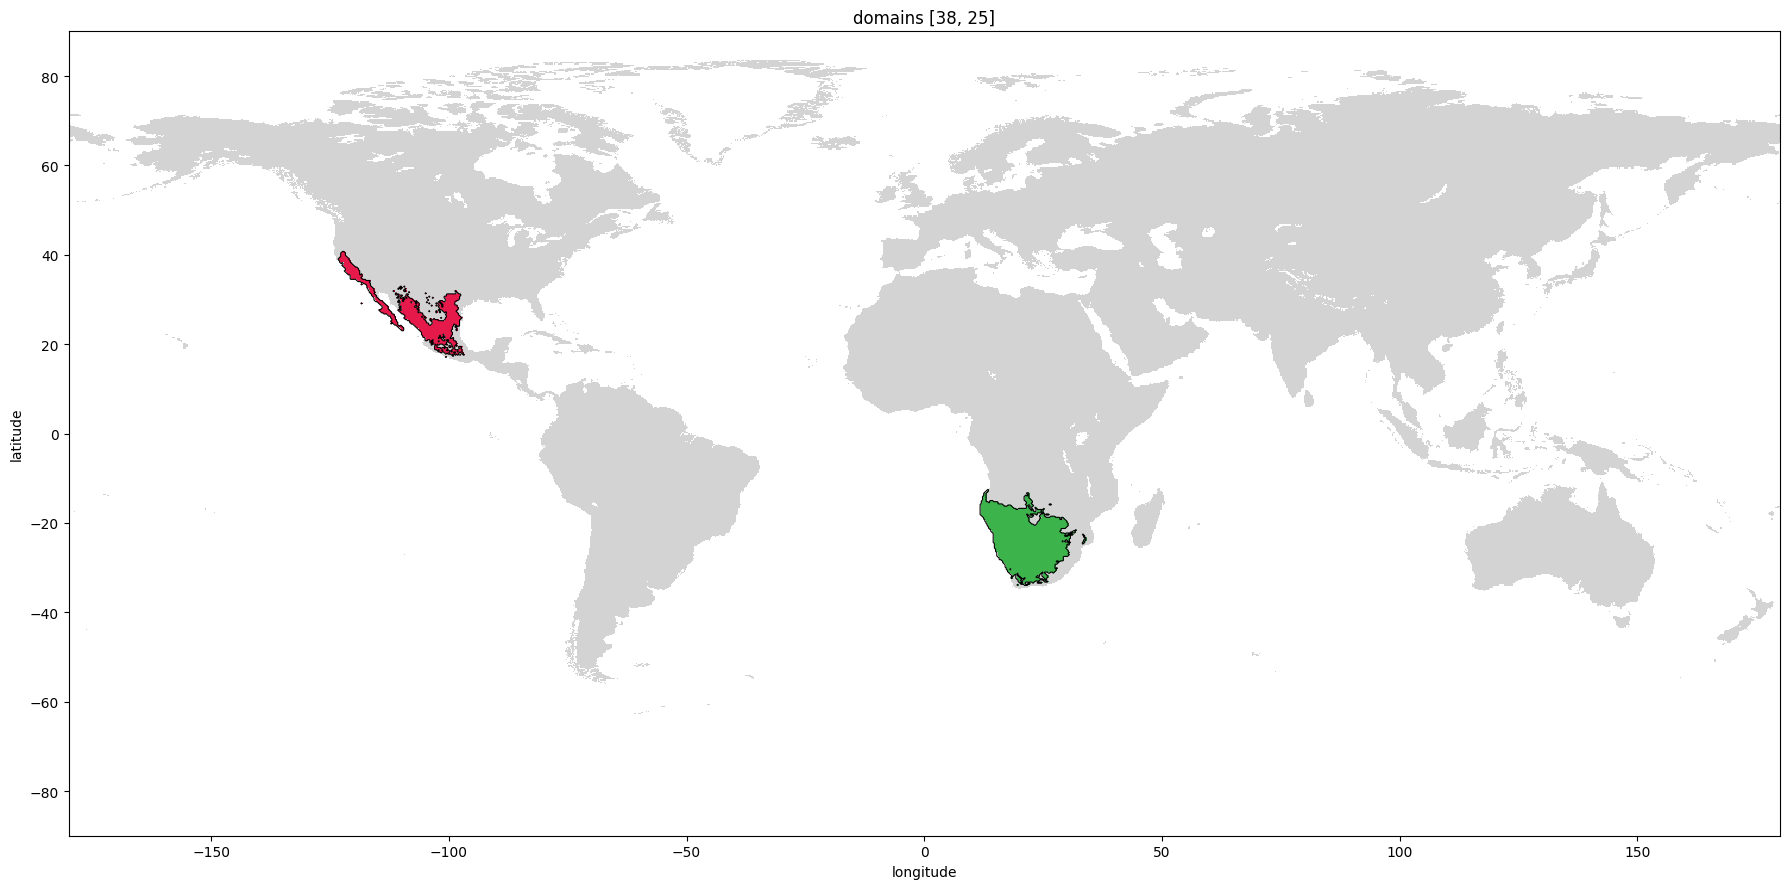

In [14]:
plot_domain([38,25])

In [ ]:
print(transfer_matrix.loc[38, '25']) # indices are numeric, cols are strings

0.2380378168342918


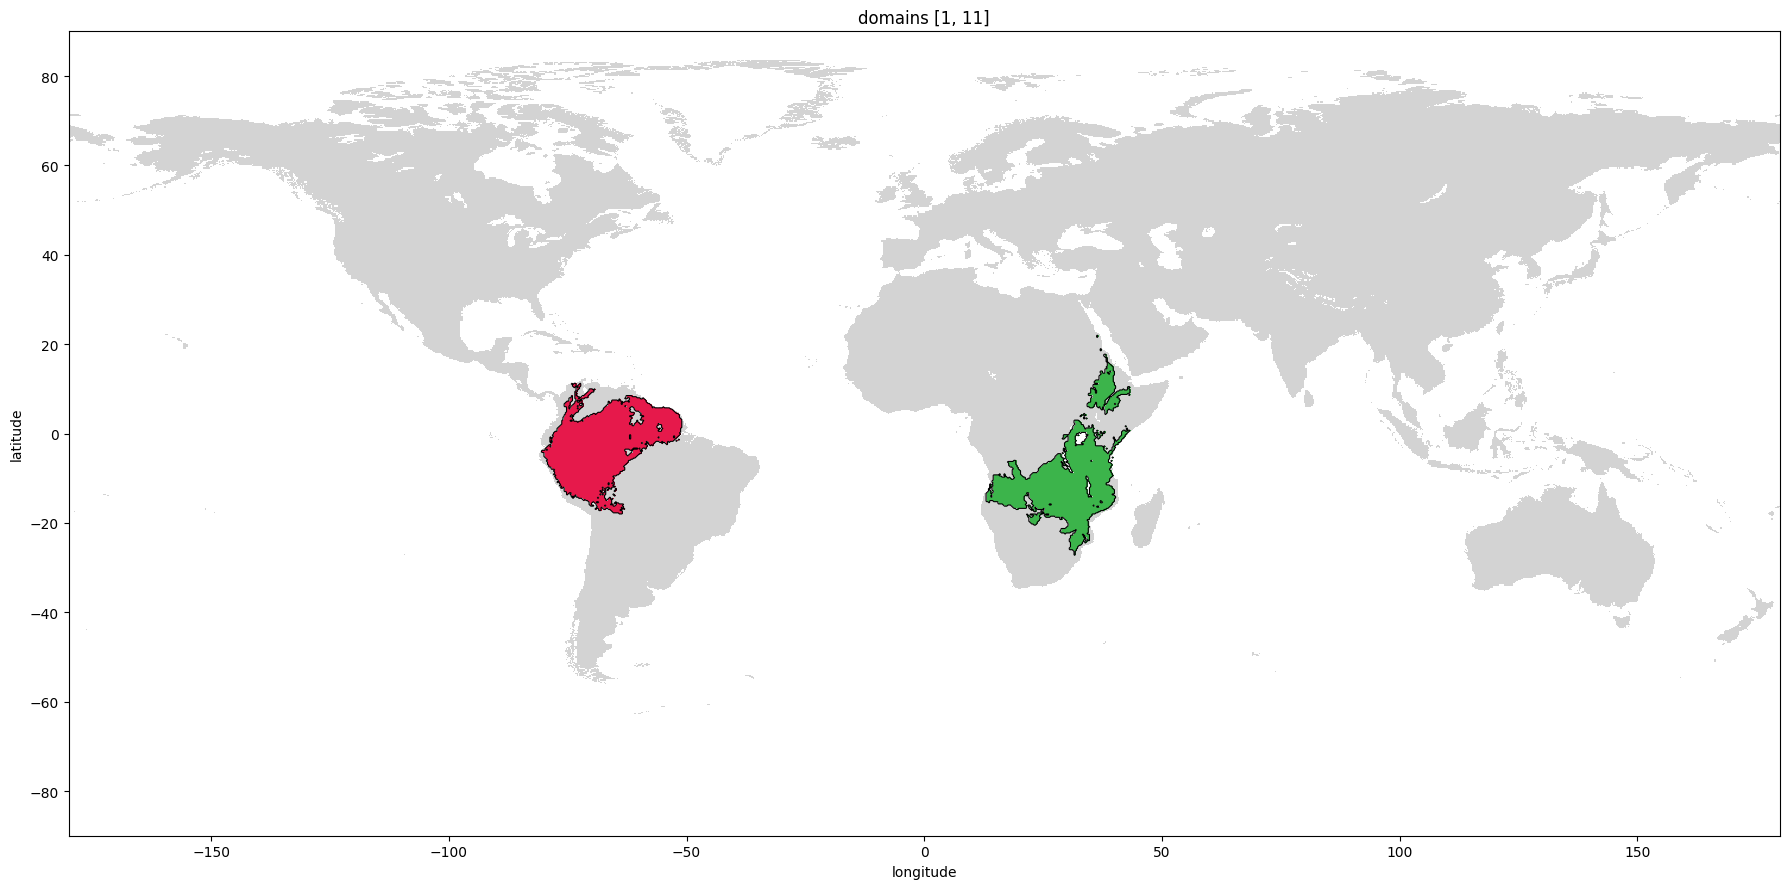

In [ ]:
plot_domain([1,11]) # id 11 is southern africa and parts of savanah, that is most data rich area

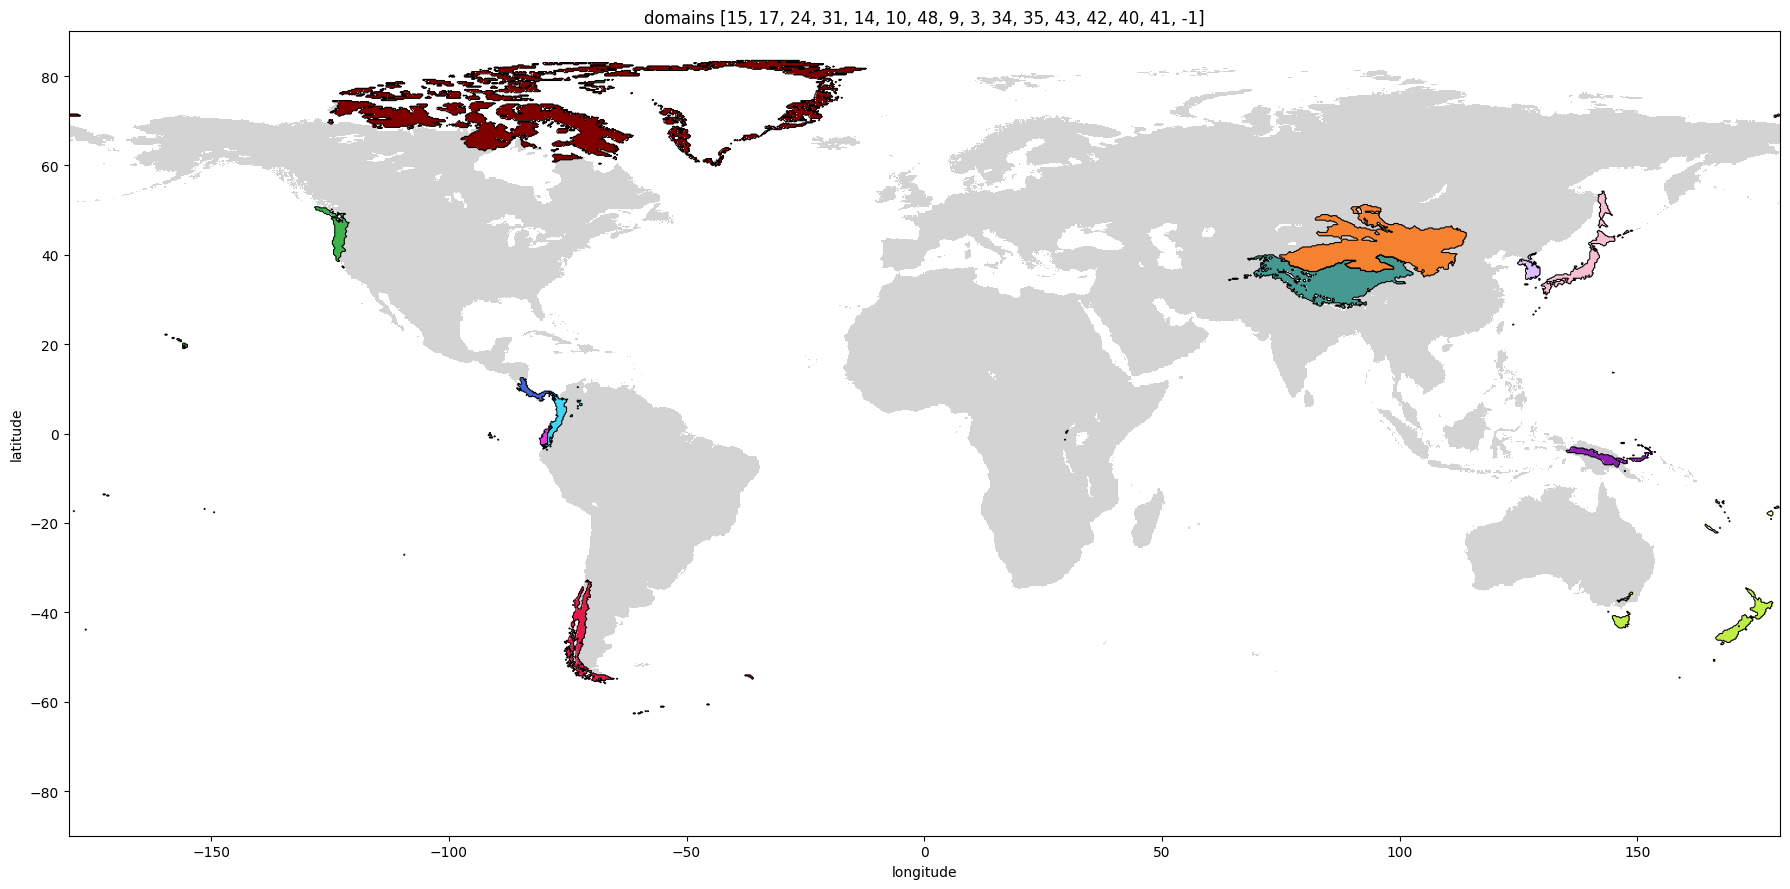

In [ ]:
plot_domain([15, 17, 24, 31, 14, 10, 48, 9, 3, 34, 35, 43, 42, 40, 41, -1]) # all domains that are not covered in transfer matrix (also the non mapped cells)
# these areas mostly make sense, apart from pnw and austrailia/nz

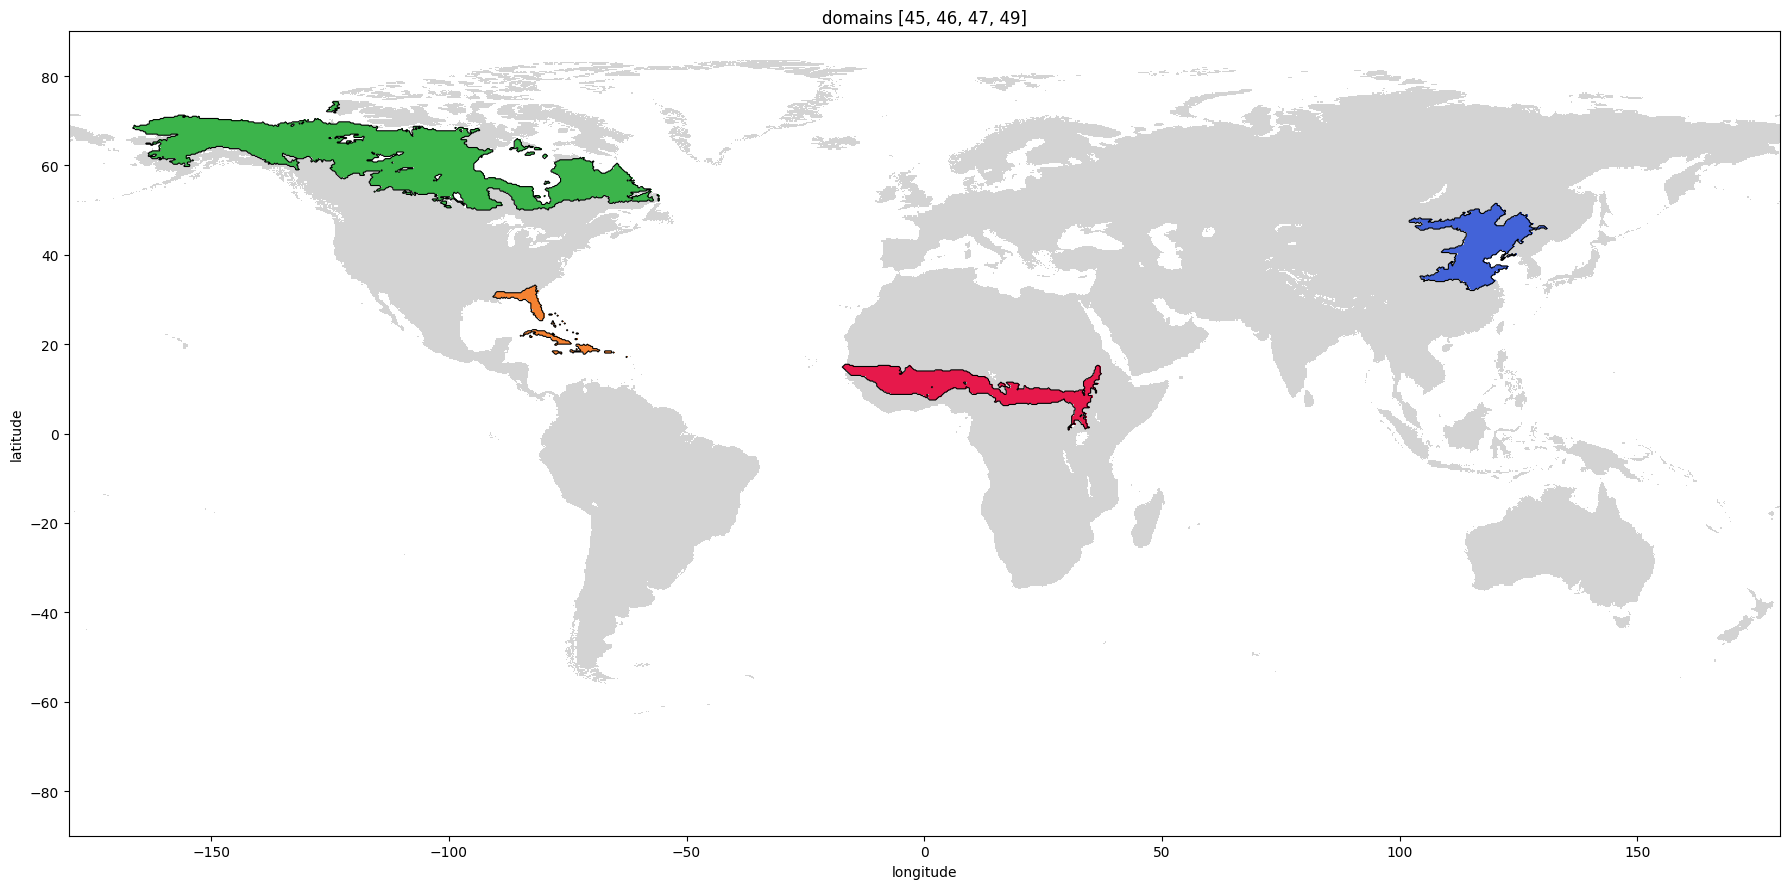

In [ ]:
plot_domain([45,46,47,49]) # last 4 domains are reasonably spread across the map, will work for test set